In [1]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from trainer import standard_trainer
from sensorium.utility.scores import get_correlations

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from autoencoder import Autoenc

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
# loading the SENSORIUM+ dataset
filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
    #"/srv/user/polina/sensorium/sensorium/notebooks/data/static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip", 

]
data_key = '23343-5-17'

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "exclude": None,
    "include_behavior": False,
    "include_eye_position": False,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": False, 
    "autoencoder": None, 
}

trainer_config = {
    'max_iter': 2,
    'verbose': False,
    'lr_decay_steps': 4,
    'avg_loss': False,
    'lr_init': 0.009,
    'device': device, 
}

In [4]:
def get_embeddings(seed, autoencoder_config):
    # Train base model
    model = stacked_core_full_gauss_readout(dataloaders, seed, **model_config)
    _, _, _ = standard_trainer(
        model, 
        dataloaders, 
        seed=seed, 
        **trainer_config
    )
    model.eval()
    
    validation_score_base = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )

    features = model.readout[data_key]._features.squeeze().permute(1, 0).detach()
    
    autoencoder = Autoenc(**autoencoder_config)
    autoencoder.to(device)

    # Train autoencoder
    criterion = torch.nn.MSELoss(reduction='sum')
    optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.3, patience=100)

    epochs = int(1e3)
    min_lr = 1e-5

    for epoch in range(epochs):
        recon = autoencoder(features)
        loss = criterion(features, recon)

        optim.zero_grad()
        loss.backward()
        optim.step()
        scheduler.step(loss.item())
        if epoch % 100 == 0:
            lr = optim.param_groups[0]['lr']
            if lr < min_lr:
                break

            print(lr, loss.item())

    model.readout[data_key].autoencoder = autoencoder

    model.eval()

    validation_score_autoenc = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )

    latent_features = autoencoder.encoder(features).detach().cpu().numpy()
    features = features.cpu().numpy()

    return features, latent_features, validation_score_base, validation_score_autoenc


In [5]:
def cluster(points, n_cluster, seed):
    kmeans = KMeans(n_clusters=n_cluster, random_state=seed)
    labels = kmeans.fit_predict(points)
    
    return labels

In [6]:
hidden_dims = 1024
hidden_layers = 2
hidden_dims = [hidden_dims] * hidden_layers

autoencoder_config = {
    'input_dim': 64, 
    'latent_dim': 4, 
    'hidden_dims': hidden_dims, 
    'batch_norm': True, 
}

In [7]:
n_cluster_range = range(2, 20)
base_label_list = []
autoenc_label_list = []
base_val_score_list = []
autoenc_val_score_list = []

# Get embeddings from 3 different seeds and cluster them
for seed in range(3):
    features, latent_features, base_score, autoenc_score = get_embeddings(
        seed=seed, autoencoder_config=autoencoder_config
    )
    
    base_labels = [cluster(features, n_cluster, seed) for n_cluster in n_cluster_range]    
    autoenc_labels = [cluster(latent_features, n_cluster, seed) for n_cluster in n_cluster_range]

    base_label_list.append(base_labels)
    autoenc_label_list.append(autoenc_labels)
    base_val_score_list.append(base_score)
    autoenc_val_score_list.append(autoenc_score)

# compute ARIs for all 3 pairs and average
aris_base = []
aris_autoenc = []

for i in range(len(n_cluster_range)):
    ari_base = (
        adjusted_rand_score(base_label_list[0][i], base_label_list[1][i])
        + adjusted_rand_score(base_label_list[0][i], base_label_list[2][i])
        + adjusted_rand_score(base_label_list[1][i], base_label_list[2][i])
    ) / 3
    aris_base.append(ari_base)

    ari_autoenc = (
        adjusted_rand_score(autoenc_label_list[0][i], autoenc_label_list[1][i])
        + adjusted_rand_score(autoenc_label_list[0][i], autoenc_label_list[2][i])
        + adjusted_rand_score(autoenc_label_list[1][i], autoenc_label_list[2][i])
    ) / 3

    aris_autoenc.append(ari_autoenc)

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 2: 100%|██████████| 35/35 [00:02<00:00, 12.02it/s]


0.001 81722.703125
0.001 300.052001953125
0.001 228.68289184570312
0.001 203.5081787109375
0.001 193.505615234375
0.001 190.02134704589844
0.001 187.59197998046875
0.001 185.9285125732422
0.001 181.54327392578125
0.001 182.31285095214844


/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 2: 100%|██████████| 35/35 [00:02<00:00, 11.74it/s]


0.001 83712.0625
0.001 359.832275390625
0.001 273.07830810546875
0.001 224.16590881347656
0.001 208.9801025390625
0.001 202.4320068359375
0.001 198.10186767578125
0.001 195.78945922851562
0.001 195.7722930908203
0.0003 190.39974975585938


/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 2: 100%|██████████| 35/35 [00:02<00:00, 11.77it/s]


0.001 70744.046875
0.001 257.7853698730469
0.001 204.38037109375
0.001 224.3170166015625
0.001 180.36386108398438
0.001 178.34120178222656
0.001 205.58282470703125
0.0003 173.88327026367188
0.0003 173.2453155517578
0.0003 172.86380004882812


In [8]:
base_val_score_list

[np.float32(0.11323005), np.float32(0.114079386), np.float32(0.1249867)]

In [9]:
autoenc_val_score_list

[np.float32(0.11161471), np.float32(0.10764242), np.float32(0.1263734)]

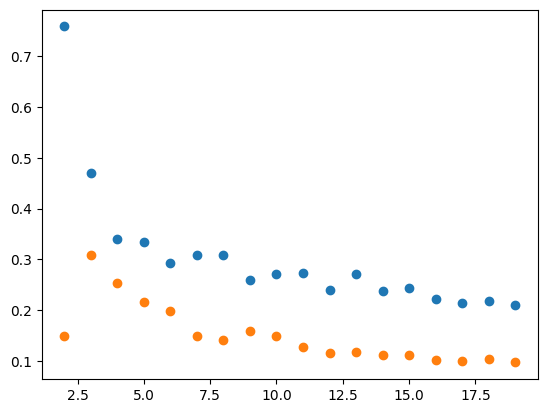

In [ ]:
plt.scatter(n_cluster_range, aris_base, label='base')
plt.scatter(n_cluster_range, aris_autoenc, label='autoencoder')